In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 38.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.11.0.86
    Uninstalling opencv-python-headless-4.11.0.86:
      Successfully uninstalled opencv-python-headless-4.11.0.86
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
%%writefile requirements.txt
roboflow
ultralytics
numpy
opencv-python>=4.1.2
pandas
Pillow
pyYAML
requests
tqdm
wandb

Writing requirements.txt


In [ ]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127

In [ ]:
ROBOFLOW_API_KEY = "<YOUR_API_KEY_HERE>"
WANDB_KEY = "<YOUR_WANDB_KEY_HERE"

## Download the dataset

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("otman-heddouch-zsoii").project("moroccan-coins-sementic-segementation")
version = project.version(1)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to moroccan-coins-sementic-segementation-1 in coco-segmentation:: 100%|██████████| 192/192 [00:00<00:00, 3475.21it/s]


### Setup W&B

In [ ]:
import wandb
wandb.login(key=WANDB_KEY)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: otmanheddouchai (otmanheddouchai-reelze-ltd) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## Sementic Segementation

| Models       | Implementation |
|------------|---------|
| [YOLO11m-seg](https://github.com/ultralytics/assets/releases/download/v8.3.0/yolo11m-seg.pt)|https://docs.ultralytics.com/tasks/segment/#models|
| Mask R-CNN | |


To track speed and accuracy, we will use [W&B](https://wandb.ai/site/).


### YOLO11m-seg Model

The data at hand is in JSON format and since YOL has its own format, we will transfer it to the correct format first

We will use [JSON2YOLO](https://github.com/ultralytics/JSON2YOLO) package from [Ultralytics](ultralytics.com) .

In [ ]:
!git clone https://github.com/otman-ai/JSON2YOLO.git

Cloning into 'JSON2YOLO'...
remote: Enumerating objects: 416, done.
remote: Counting objects: 100% (254/254), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 416 (delta 228), reused 178 (delta 171), pack-reused 162 (from 2)
Receiving objects: 100% (416/416), 123.81 KiB | 681.00 KiB/s, done.
Resolving deltas: 100% (249/249), done.


#### Transform COCO annotation to YOLO format

In [ ]:
!python /content/JSON2YOLO/general_json2yolo.py --dir "/content/moroccan-coins-sementic-segementation-1/test" --save_dir "/content/morocco-coin-seg-yolo/test"
!python /content/JSON2YOLO/general_json2yolo.py --dir "/content/moroccan-coins-sementic-segementation-1/train" --save_dir "/content/morocco-coin-seg-yolo/train"
!python /content/JSON2YOLO/general_json2yolo.py --dir "/content/moroccan-coins-sementic-segementation-1/valid" --save_dir "/content/morocco-coin-seg-yolo/valid"

Annotations /content/moroccan-coins-sementic-segementation-1/test/_annotations.coco.json: 100% 7/7 [00:00<00:00, 1244.50it/s]
Annotations /content/moroccan-coins-sementic-segementation-1/train/_annotations.coco.json: 100% 156/156 [00:00<00:00, 1082.21it/s]
Annotations /content/moroccan-coins-sementic-segementation-1/valid/_annotations.coco.json: 100% 15/15 [00:00<00:00, 2006.65it/s]


##### Creating the YAML file

In [ ]:
import yaml

yolo_yaml_file = '/content/morocco-coin-seg-yolo/seg-yolo.yaml'
yolo_dir = '/content/morocco-coin-seg-yolo'
SEED = 42

In [ ]:
data = {
    'path':yolo_dir,
    'train':'train/images',
    'val':'valid/images',
    'test':'test/images',
    'names':{
              0: 'five',
              1:'half',
              2:'one',
              3:'quarter',
              4:'ten'
            }
}
with open(yolo_yaml_file, 'w') as file:
    yaml.dump(data, file, default_flow_style=False, sort_keys=False)

In [ ]:
# set wandb in ultralytics
!yolo settings wandb=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Updated 'wandb=True'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": true,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [ ]:
from ultralytics import YOLO
import torch
torch.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load a model
model = YOLO("yolo11n-seg.pt")
# Train the model
results = model.train(data=yolo_yaml_file,
                      epochs=100,
                      imgsz=640,
                      device=device)

100%|██████████| 5.90M/5.90M [00:00<00:00, 108MB/s]


Ultralytics 8.3.157 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/morocco-coin-seg-yolo/seg-yolo.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pos

100%|██████████| 755k/755k [00:00<00:00, 19.9MB/s]

Overriding model.yaml nc=80 with nc=5

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

 23        [16, 19, 22]  1    684415  ultralytics.nn.modules.head.Segment          [5, 32, 64, [64, 128, 256]]   
YOLO11n-seg summary: 203 layers, 2,843,583 parameters, 2,843,567 gradients, 10.4 GFLOPs

Transferred 510/561 items from pretrained weights


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/1 [00:00<?, ?it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  3.48it/s]


                   all         15         68      0.953      0.978       0.98      0.977      0.953      0.978       0.98       0.97
                  five          8         12      0.921          1      0.989      0.989      0.921          1      0.989      0.989
                  half         12         13      0.863          1       0.99       0.99      0.863          1       0.99       0.96
                   one          7         27          1      0.891      0.932      0.918          1      0.891      0.932       0.91
               quarter          8          8      0.994          1      0.995      0.995      0.994          1      0.995      0.995
                   ten          5          8      0.986          1      0.995      0.995      0.986          1      0.995      0.995
Speed: 0.2ms preprocess, 3.0ms inference, 0.0ms loss, 2.8ms postprocess per image
Results saved to runs/segment/train


lr/pg0,▂▃▄▅█████▇▇▇▇▆▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁
lr/pg1,▁▂▄▅▆▇█████▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▁
lr/pg2,▅████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁
metrics/mAP50(B),▁▁▆▆▇▇▇█████▇███████████████████████████
metrics/mAP50(M),▁▄▄▆▆▇▇▇▇▇▇▇▇████▇▇▇████████████████████
metrics/mAP50-95(B),▁▁▂▄▄▆▆▇▇▇▇████▇████████████████████████
metrics/mAP50-95(M),▁▁▄▆▆▇▇▆██▇▇▇███████████████████████████
metrics/precision(B),▁▁▁▆▆▆▆▆▇▇█▇▇██▇█▇██████████████████████
metrics/precision(M),▁▁▁▁▁▆▆▆▇▅▆▇█▇▇██▇▇█████████████████████
metrics/recall(B),▁▆███▃▂▆▅▅▇▇▇▇▇▇▇▇█▇▇██▇██████▇███▇█████
metrics/recall(M),███▁▃▅▇▇▆▇▇▇▇█▇▇▇▇██▇▇█████████▇████████


In [ ]:
import pandas as pd

In [ ]:
results = pd.read_csv("/content/runs/segment/train/results.csv")

In [ ]:
results.head()

,epoch,time,train/box_loss,train/seg_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),...,metrics/recall(M),metrics/mAP50(M),metrics/mAP50-95(M),val/box_loss,val/seg_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,9.44747,0.61006,1.24283,3.74015,0.95672,0.02006,0.54167,0.15537,0.14775,...,0.54167,0.15690,0.14730,0.25271,0.53956,3.43785,0.75883,0.000100,0.000100,0.000100
1,2,14.69840,0.46516,0.57146,3.17969,0.84953,0.06295,0.88490,0.23639,0.20610,...,0.89231,0.23391,0.21699,0.39623,0.46335,3.25839,0.74519,0.000209,0.000209,0.000209
2,3,19.12520,0.45823,0.47820,2.74015,0.84335,0.03054,0.97721,0.32085,0.29630,...,0.97721,0.32085,0.30760,0.39284,0.34625,3.21305,0.74717,0.000316,0.000316,0.000316
3,4,24.84240,0.47073,0.43781,2.30991,0.86052,0.03121,0.97721,0.33108,0.31449,...,0.97721,0.33147,0.31767,0.36785,0.37432,3.13811,0.75226,0.000420,0.000420,0.000420
4,5,29.21380,0.46313,0.43249,1.92128,0.85363,0.02715,0.96980,0.31877,0.29420,...,0.97721,0.32052,0.29691,0.40589,0.52802,3.05945,0.75743,0.000523,0.000523,0.000523



| Training Segment Loss       | Training Class Loss | Training Box loss |
|------------|---------|-------|
|1.242830|3.740150|0.610060|


| Validation Segment Loss       | Validation Class Loss | Validation Box loss |
|------------|---------|-------|
|0.564700|3.437850|0.405890|

### Segement Anything
Segment Anything is the state-of-the-art segmentation model that was created by Meta in 2023. The model segment the input image based on a prompt, and it can be box, mask or just point.
For more information about SA model I have created an article [here](https://medium.com/@otmanheddouchai/segement-anything-8c58161ac972?source=user_profile_page---------5-------------e7d361ca183e----------------------) .

We will use the model to expirement with our problem.
But how are we going to do that ?
Well, easy, use SA to segment the coins using corresponding prompt. The segmented elements will then be used to feed to a classifier to get the highest label .

In [ ]:
# installation
!pip install git+https://github.com/facebookresearch/sam2.git

  Cloning https://github.com/facebookresearch/sam2.git to /tmp/pip-req-build-af5kibh2
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/sam2.git /tmp/pip-req-build-af5kibh2
  Resolved https://github.com/facebookresearch/sam2.git to commit 2b90b9f5ceec907a1c18123530e92e794ad901a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
from sam2.sam2_image_predictor import SAM2ImagePredictor

predictor = SAM2ImagePredictor.from_pretrained("facebook/sam2-hiera-large")

In [ ]:
import cv2

with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
    # Read the image using OpenCV
    image_path = "/content/assets/IMG_20250619_204522_412_jpg.rf.eac21e33cbe33fbedf0620555d0f7d26.png"
    image = cv2.imread(image_path)
    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    predictor.set_image(image)
    masks, _, _ = predictor.predict()

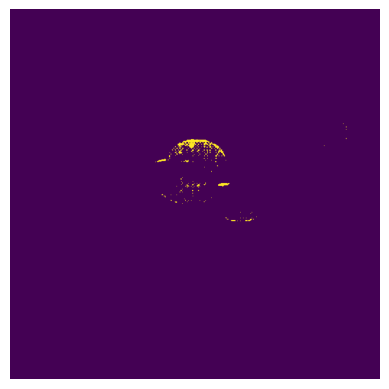

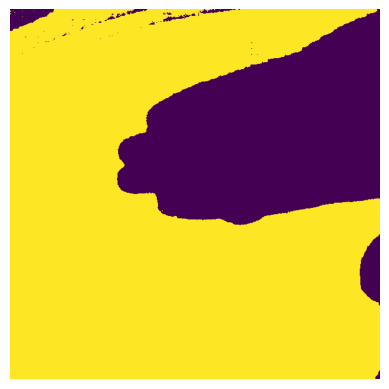

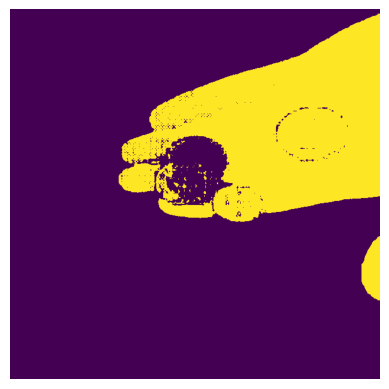

In [ ]:
for mask in masks:
  plt.imshow(mask)
  plt.axis('off')
  plt.show()

Segment Anything performs poorly on our task and it can't distinguish between the coins without explicitly give it a prompt like points of the object .

### Mask R-CNN
Extended Faster R-CNN by adding a branch of detecting object mask, learn more [here](https://arxiv.org/abs/1703.06870) .
Since we already have dataset in coco format, we will just load it the correct format with ease .

In [ ]:
import random
from torchvision.models.detection import maskrcnn_resnet50_fpn
import numpy as np
import torch.utils.data
import torchvision.models.segmentation
import torch

from torch.utils.data import  Dataset
import cv2
import os
import json
import pandas as pd
from collections import defaultdict
from torch.utils.data import DataLoader, Dataset, RandomSampler
import wandb
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import torchvision.transforms.functional as F



def calculate_avg(dict):
  # Initialize sums
  sums = {}
  for loss_dict in dict:
      for k, v in loss_dict.items():
          sums[k] = sums.get(k, 0) + v

  # Calculate averages
  n = len(dict)
  averages = {k: v / n for k, v in sums.items()}
  return averages

class CoinCOCDataet(Dataset):
    def __init__(self, annotation_file,data_dir, new_shape=(640, 640)):
      self.annotation_file = annotation_file
      self.new_shape = new_shape
      self.data_dir = data_dir
      self.annotation_data = None
      with open(self.annotation_file) as f:
        self.annotation_data = json.load(f)

      self.image_paths = []
      for image in self.annotation_data["images"]:
        self.image_paths.append(os.path.join(self.data_dir,image["file_name"]))
      print("Images path loaded successfully.")

      # load the annotations
      self.annotations = defaultdict(list)
      for ann in self.annotation_data["annotations"]:
        self.annotations[ann["image_id"]].append(ann)
      print("Annotations loaded successfully.")

    def __getitem__(self, idx):
      data = {}
      # check if it is exists
      if idx >= len(self.image_paths):
          raise IndexError("File doasn't exists")
      # read the image
      image = cv2.imread(self.image_paths[idx])
      # resize the image to a fixed shape
      # image = cv2.resize(image, self.new_shape, cv2.INTER_LINEAR)
        # Convert BGR to RGB (torchvision models expect RGB)
      image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
      # Convert to float32 and normalize to [0, 1]
      image = image.astype(np.float32) /255.

      # Convert from [H, W, C] to [C, H, W]
      image = torch.from_numpy(image).permute(2, 0, 1)
      # get number of objects exists in the image
      num_objs = len(self.annotations[idx])
      # create empty tensor for bbox (xmin, ymin, xmax, ymax)
      boxes = torch.zeros([num_objs, 4], dtype=torch.float32)
      # create empty tensor for label of each object
      labels = torch.zeros([num_objs], dtype=torch.int64)
      areas = torch.zeros([num_objs], dtype=torch.int64)

      # create empty mask in the format of [N, W, H] where N is the number of objects
      masks = np.zeros([num_objs, image.shape[0], image.shape[1]], dtype=np.uint8)
      # loop through all the annotations we have
      for i, ann in enumerate(self.annotations[idx]):
        x, y, w, h = ann["bbox"] # get the bbox
        boxes[i] =  torch.tensor([x, y, x+w, y+h]) # assign the bbox to the correct index
        if ann["category_id"] < 1:
          print("We found category id with 0")
        labels[i] = ann["category_id"] # assign the label
        # render the segmentation into the mask for all the objects with different classes
        segmentation = ann["segmentation"]
        # Convert the polygon coordinates to the format expected by fillPoly
        polygons = [np.array(seg).reshape(-1, 1, 2).astype(np.int32) for seg in segmentation]
        # fill the cooresponding mask with the correct pixels
        cv2.fillPoly(masks[i], polygons, 1)
        areas[i] = ann["area"]
      # conver th mask to tensor
      data["masks"] = torch.as_tensor(masks, dtype=torch.uint8)
      data["boxes"] = boxes
      data["labels"] = labels
      data["image_id"] = torch.tensor([idx])
      data["area"] = torch.as_tensor(areas, dtype=torch.float32)
      data["iscrowd"] = torch.zeros((num_objs,), dtype=torch.int64)

      return image, data

    def __len__(self):
        return len(self.image_paths)

# w&b login
wandb.login(key=WANDB_KEY)



SEED = 42
EPOCHS = 40
lr =  0.005
early_stopping = 10
model_path = "checkpoints/model.pth"
os.makedirs("checkpoints", exist_ok=True)

# setting the seed
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

batch_size = 2
image_size = [640,640]

# load the training dataset
train_dataset = CoinCOCDataet("/content/moroccan-coins-sementic-segementation-1/train/_annotations.coco.json",
                        "/content/moroccan-coins-sementic-segementation-1/train")
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# load the validation dataset
valid_dataset = CoinCOCDataet("/content/moroccan-coins-sementic-segementation-1/valid/_annotations.coco.json",
                        "/content/moroccan-coins-sementic-segementation-1/valid")
valid_data_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))


# set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 6

model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=True)  # load an instance segmentation model pre-trained pre-trained on COCO
in_features = model.roi_heads.box_predictor.cls_score.in_features  # get number of input features for the classifier
model.roi_heads.box_predictor = FastRCNNPredictor(in_features ,num_classes=num_classes)  # replace the pre-trained head with a new one
model.to(device)# move model to the right device

optimizer = torch.optim.AdamW(params=model.parameters(), lr=1e-5)
model.train()

run = wandb.init(
    project="maskrcnn-training",
    name="train",
    config={
        "epochs": EPOCHS,
        "batch_size": batch_size,
        "lr":lr,
        "optimizer": "AdamW",
        "model": "maskrcnn_resnet50_fpn"
    }
)

cuda_count = torch. cuda. device_count()
gpu_devices = ','.join([str(id) for id in range(0, cuda_count)])
os.environ["CUDA_VISIBLE_DEVICES"] = gpu_devices


losses = {
    "val_loss":[],
    "train_loss":[]
}
best_loss = 10000
epoch_waited = 0

# Training loop
model.train()
print("Start training the model for ",EPOCHS)
for epoch in range(EPOCHS):
  model.train()
  train_losses = []
  for images, targets in train_data_loader:
      images = list(img.to(device) for img in images)
      targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
      optimizer.zero_grad()
      torch.cuda.empty_cache()

      loss_dict = model(images, targets)
      train_losses.append(loss_dict)
      loss = sum(loss for loss in loss_dict.values())
      loss.backward()
      optimizer.step()

      run.log({"train_"+k: v.item() for k, v in loss_dict.items()})

  # validation step
  valid_losses = []
  for valid_images, valid_targets in valid_data_loader:
      valid_images = list(img.to(device) for img in valid_images)
      valid_targets = [{k: v.to(device) for k, v in t.items()} for t in valid_targets]
      torch.cuda.empty_cache()
      valid_loss_dict = model(valid_images, valid_targets)
      valid_losses.append(valid_loss_dict)

      loss = sum(loss for loss in valid_loss_dict.values())
      run.log({"valid_"+k: v.item() for k, v in valid_loss_dict.items()})


  avg_train_loss = calculate_avg(train_losses)
  avg_valid_loss = calculate_avg(valid_losses)
  sum_avg_train_loss =  sum(loss for loss in avg_train_loss.values())
  sum_avg_valid_loss =  sum(loss for loss in avg_valid_loss.values())

  # log the total loss
  run.log({"valid loss": sum_avg_valid_loss})
  run.log({"train loss ": sum_avg_train_loss})
  print(f"Epoch: {epoch} Training loss:{sum_avg_train_loss}, Validation loss {sum_avg_valid_loss} ") #Validation loss:{avg_valid_loss.loss_mask}===

  # Append the loss for later ploting
  losses["train_loss"].append(avg_train_loss)
  losses["val_loss"].append(avg_valid_loss)

  if best_loss > sum_avg_valid_loss:
      best_loss = sum_avg_valid_loss
      print(f"Saving the best model to {model_path}")
      torch.save(model.state_dict().copy(), model_path)
      run.save(model_path)

  else:
      epoch_waited += 1
  # break if no improvement happen
  if epoch_waited >= early_stopping:
      print("Breaking... No improvement")
      pd.DataFrame(losses).to_csv("losses.csv")
      run.save("results.csv")
      break

run.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


Images path loaded successfully.
Annotations loaded successfully.
Images path loaded successfully.
Annotations loaded successfully.


Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:00<00:00, 182MB/s]


Start training the model for  40
Epoch: 0 Training loss:1.2848225831985474, Validation loss 0.8117406368255615 
Saving the best model to checkpoints/model.pth


OutOfMemoryError: CUDA out of memory. Tried to allocate 50.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 38.12 MiB is free. Process 10995 has 14.70 GiB memory in use. Of the allocated memory 14.32 GiB is allocated by PyTorch, and 255.31 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
new_loss = [{k: v.to('cpu').detach().numpy()  for k, v in t.items()} for t in losses["val_loss"]]

dataframe = pd.DataFrame(new_loss)

In [ ]:
dataframe

,loss_classifier,loss_box_reg,loss_mask,loss_objectness,loss_rpn_box_reg
0,0.3349251,0.47256997,0.00073438074,0.0004811603,0.00303001


### Inference

In [ ]:
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_KEY'))


In [ ]:
# Mask R-CNN
wandb.restore('checkpoints/model.pth', run_path='otmanheddouchai-reelze-ltd/maskrcnn-training/lzi18wqj')

<_io.TextIOWrapper name='/content/checkpoints/model.pth' mode='r' encoding='utf-8'>

In [ ]:
import wandb
run = wandb.init()
# YOLO
artifact = run.use_artifact('otmanheddouchai-reelze-ltd/yolo11n-seg/run_bvmdo1ab_model:v0', type='model')
artifact_dir = artifact.download()

wandb:   1 of 1 files downloaded.  


#### Loading the models


##### YOLO

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 72.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [ ]:
from ultralytics import YOLO
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load a model
yolo_network = YOLO("/content/artifacts/run_bvmdo1ab_model:v0/best.pt")
yolo_network.to(device)

YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_runni

In [ ]:
# run the model and show the segmentation
%%time
yolo_results = yolo_network("/content/IMG_20250619_204522_412_jpg.rf.eac21e33cbe33fbedf0620555d0f7d26.png", save=True)


image 1/1 /content/IMG_20250619_204522_412_jpg.rf.eac21e33cbe33fbedf0620555d0f7d26.png: 640x640 2 fives, 1 half, 1 quarter, 12.4ms
Speed: 3.7ms preprocess, 12.4ms inference, 3.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/segment/predict
CPU times: user 56.2 ms, sys: 2.65 ms, total: 58.8 ms
Wall time: 50.4 ms


##### Mask R-CNN

In [ ]:
import cv2
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor


mask_rcnn_network = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=True)  # load an instance segmentation model pre-trained pre-trained on COCO
in_features = model.roi_heads.box_predictor.cls_score.in_features  # get number of input features for the classifier
mask_rcnn_network.roi_heads.box_predictor = FastRCNNPredictor(in_features ,num_classes=6)  # replace the pre-trained head with a new one
mask_rcnn_network.to(device)# move model to the right device

mask_rcnn_network.load_state_dict(torch.load("/content/checkpoints/model.pth", map_location=device))
mask_rcnn_network

In [ ]:

import numpy as np
def mask_rcnn_image_process(file):
    # read the image
    image = cv2.imread(file)
    # resize the image to a fixed shape
    # image = cv2.resize(image, self.new_shape, cv2.INTER_LINEAR)
      # Convert BGR to RGB (torchvision models expect RGB)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Convert to float32 and normalize to [0, 1]
    image = image.astype(np.float32) /255.

    # Convert from [H, W, C] to [C, H, W]
    image = torch.from_numpy(image).permute(2, 0, 1).reshape(-1,3, 640, 640)

    return image



In [ ]:
mask_rcnn_network.eval()

AssertionError: targets should not be none when in training mode

In [ ]:
input = mask_rcnn_image_process("/content/IMG_20250619_204522_412_jpg.rf.eac21e33cbe33fbedf0620555d0f7d26.png")
mask_rcnn_results = mask_rcnn_network(input.to(device))

In [ ]:
torch.argmax(mask_rcnn_results[0]["scores"])

tensor(0, device='cuda:0')

In [ ]:
mask_rcnn_results[0]["scores"] > 0.5

tensor([False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False, False, False], device='cuda:0')

In [ ]:
num_objts = sum(mask_rcnn_results[0]["scores"] > 0.30).cpu().numpy()

array([[[          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        ...,
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0],
        [          0,           0,           0, ...,           0,           0,           0]]], dtype=float32)

In [ ]:
masks = mask_rcnn_results[0]["masks"][:num_objts]
len(masks)

5

In [ ]:
image = cv2.imread("/content/IMG_20250619_204522_412_jpg.rf.eac21e33cbe33fbedf0620555d0f7d26.png")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image.shape

(640, 640, 3)

In [ ]:
color_map = {
    1: [0, 0, 0],        # black
    2: [255, 0, 0],      # red
    3: [0, 255, 0],      # green
    4: [0, 0, 255],      # blue
    5: [255, 255, 0],    # yellow
}

In [ ]:
mask_rcnn_results[0]["labels"][:num_objts]

tensor([3, 3, 3, 3, 3], device='cuda:0')

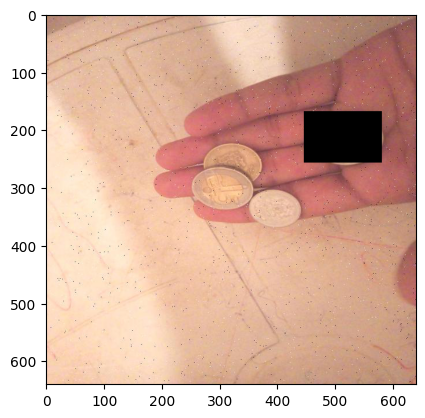

In [ ]:
# colored_mask = np.zeros_like(image)
image[masks[0].cpu().detach().numpy()[0] > 0] = [0 , 0, 0]  # green mask

# overlay = cv2.addWeighted(image, 1.0, colored_mask, 1, 1)
plt.imshow( image)